In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Subscription Churn and Revenue Retention Analysis - Sheet1.csv")
df.head()

,Subscriber_id,Subscription_duration,Monthly_subscription_fee,Subscription_plan,Payment_method,Total_revenue,Subscription_cancelled,Status,Revenue_lost
0,7590-VHVIUA,1,29.85,Month-to-month,Electronic check,29.85,No,Active,0.00
1,5575-GNVDE,34,56.95,One year,Mailed check,1889.50,No,Active,0.00
2,3668-QPYBK,2,53.85,Month-to-month,Mailed check,108.15,Yes,Churned,53.85
3,7795-CFOCW,45,42.30,One year,Bank transfer (automatic),1840.75,No,Active,0.00
4,9237-HQITU,2,70.70,Month-to-month,Electronic check,151.65,Yes,Churned,70.70


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Subscriber_id             7043 non-null   str    
 1   Subscription_duration     7043 non-null   int64  
 2   Monthly_subscription_fee  7043 non-null   float64
 3   Subscription_plan         7043 non-null   str    
 4   Payment_method            7043 non-null   str    
 5   Total_revenue             7032 non-null   float64
 6   Subscription_cancelled    7043 non-null   str    
 7   Status                    7043 non-null   str    
 8   Revenue_lost              7043 non-null   float64
dtypes: float64(3), int64(1), str(5)
memory usage: 495.3 KB


In [6]:
df['Status'].value_counts()

Status
Active     5174
Churned    1869
Name: count, dtype: int64

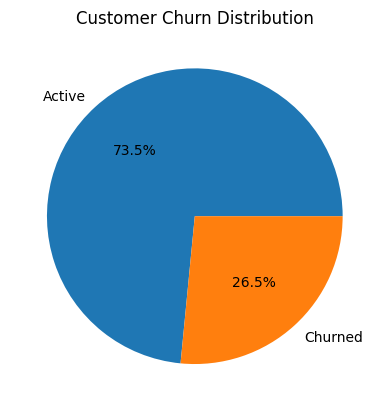

In [7]:
df['Status'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Customer Churn Distribution")
plt.ylabel("")
plt.show()

In [8]:
df.groupby('Subscription_plan')['Status'].value_counts()

Subscription_plan  Status 
Month-to-month     Active     2220
                   Churned    1655
One year           Active     1307
                   Churned     166
Two year           Active     1647
                   Churned      48
Name: count, dtype: int64

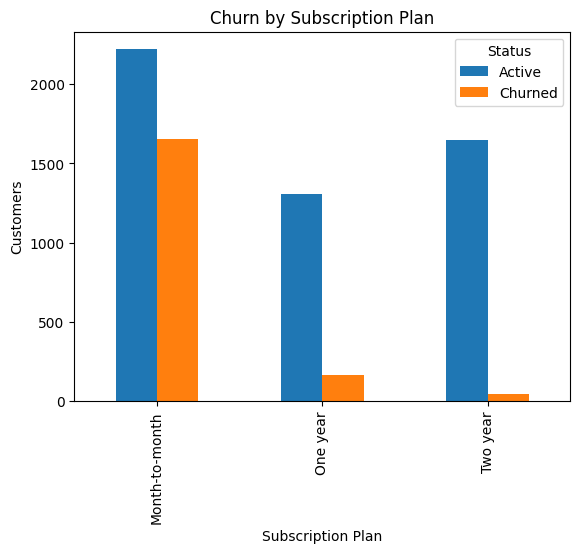

In [9]:
df.groupby('Subscription_plan')['Status'].value_counts().unstack().plot(kind='bar')

plt.title("Churn by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Customers")
plt.show()

In [10]:
df.groupby('Subscription_plan')['Monthly_subscription_fee'].sum()

Subscription_plan
Month-to-month    257294.15
One year           95816.60
Two year          103005.85
Name: Monthly_subscription_fee, dtype: float64

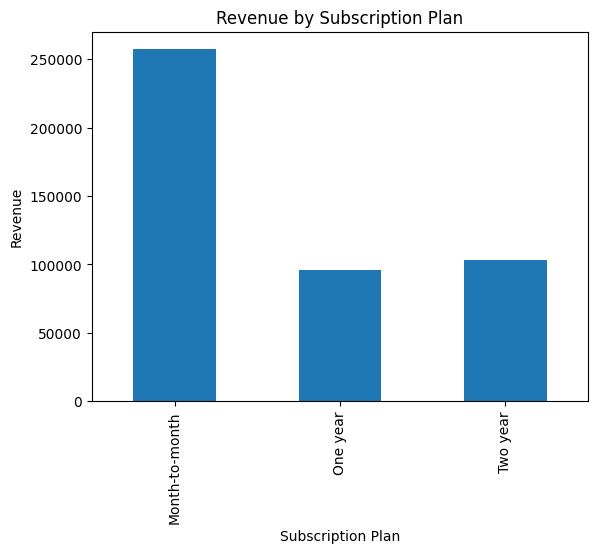

In [11]:
df.groupby('Subscription_plan')['Monthly_subscription_fee'].sum().plot(kind='bar')

plt.title("Revenue by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Revenue")
plt.show()

In [13]:
df.groupby('Subscription_plan')['Revenue_lost'].sum()

Subscription_plan
Month-to-month    120847.10
One year           14118.45
Two year            4165.30
Name: Revenue_lost, dtype: float64

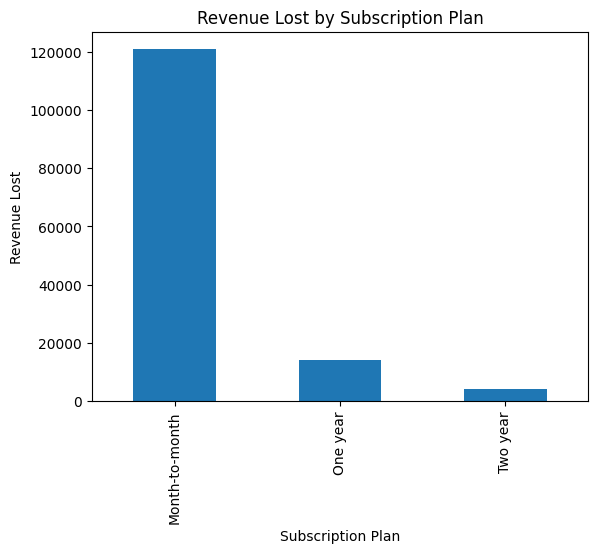

In [14]:
df.groupby('Subscription_plan')['Revenue_lost'].sum().plot(kind='bar')

plt.title("Revenue Lost by Subscription Plan")
plt.xlabel("Subscription Plan")
plt.ylabel("Revenue Lost")
plt.show()

Key Insights
1) Month-to-month subscription plans have the highest churn rate.
2) Long-term subscription plans retain customers better.
3) A significant portion of revenue loss comes from customers on monthly plans.
4) Improving retention strategies for short-term plans could reduce churn.

In [15]:
!pip install pandasql

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   ---------------------------------- ----- 1.8/2.1 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 6.0 MB/s  0:00:00
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=27296 sha256=0c66afd45fec58a5ca5dcb44ced316feec8bda227c5d80caf688922e5ef8df9d
  Stored in directory: c:\users\amir\appdata\local\pip\cache\wheels\59\e5\4c\49bb806b26fc23e0e774762cd2928b50b204bb36666408ca13
Successfully built pandasql

   ---------------------------------------- 0/3 [greenlet]
   ----------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Amir\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [17]:
import pandas as pd
import pandasql as ps

In [ ]:
Churn by plan--

In [22]:
query = """
SELECT subscription_plan, COUNT(*) AS churned_customers
FROM df
WHERE status = 'Churned'
GROUP BY subscription_plan
"""

ps.sqldf(query, locals())

,Subscription_plan,churned_customers
0,Month-to-month,1655
1,One year,166
2,Two year,48


In [ ]:
Revenue by plan--

In [19]:
query = """
SELECT subscription_plan,
SUM(monthly_subscription_fee) AS total_revenue
FROM df
GROUP BY subscription_plan
"""

ps.sqldf(query, locals())

,Subscription_plan,total_revenue
0,Month-to-month,257294.15
1,One year,95816.60
2,Two year,103005.85


In [ ]:
Revenue lost--

In [20]:
query = """
SELECT subscription_plan,
SUM(revenue_lost) AS revenue_lost
FROM df
GROUP BY subscription_plan
"""

ps.sqldf(query, locals())

,Subscription_plan,revenue_lost
0,Month-to-month,120847.10
1,One year,14118.45
2,Two year,4165.30


In [ ]:
Queries performed:

1) Churned customers by subscription plan
2) Revenue generated by subscription plans
3) Revenue loss due to churn